<a href="https://colab.research.google.com/github/KavindaKGD/Franklin-Models/blob/Triplet/TripletNetwork%2BConv_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, random, itertools
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__)


TF: 2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/fp_dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")

CLASS_NAMES = ["fp", "healthy", "barnacles"]
N_WAY = 3

for c in CLASS_NAMES:
    print(c, "train:", len(os.listdir(os.path.join(TRAIN_DIR, c))),
             "val:", len(os.listdir(os.path.join(VAL_DIR, c))))


fp train: 4 val: 2
healthy train: 4 val: 2
barnacles train: 4 val: 2


In [ ]:
def list_images_by_class(base_dir, class_names):
    by_class = {}
    for idx, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, cname)
        files = []
        for f in os.listdir(cdir):
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                files.append(os.path.join(cdir, f))
        by_class[idx] = sorted(files)
    return by_class

train_by_class = list_images_by_class(TRAIN_DIR, CLASS_NAMES)
val_by_class   = list_images_by_class(VAL_DIR, CLASS_NAMES)

print("Train by class:", {k: len(v) for k, v in train_by_class.items()})
print("Val by class:", {k: len(v) for k, v in val_by_class.items()})


Train by class: {0: 4, 1: 4, 2: 4}
Val by class: {0: 2, 1: 2, 2: 2}


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
])

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img


In [ ]:
def build_conv4_encoder(embedding_dim=128):
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inp
    for filters in [32, 64, 128, 256]:
        x = tf.keras.layers.Conv2D(filters, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPool2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(embedding_dim)(x)
    out = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(x)
    return tf.keras.Model(inp, out, name="Conv4_Encoder")

encoder = build_conv4_encoder(embedding_dim=128)
encoder.summary()


Model: "Conv4_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,232 (1.61 MB)

 Trainable params: 422,272 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
def build_all_triplets(by_class):
    triplets = []
    classes = list(by_class.keys())

    for c in classes:
        pos_files = by_class[c]
        neg_files = []
        for other in classes:
            if other != c:
                neg_files += by_class[other]

        # ordered anchor-positive pairs (a != p)
        for a in pos_files:
            for p in pos_files:
                if a == p:
                    continue
                for n in neg_files:
                    triplets.append((a, p, n))

    random.shuffle(triplets)
    return triplets

train_triplets = build_all_triplets(train_by_class)
val_triplets   = build_all_triplets(val_by_class)

print("Train triplets:", len(train_triplets))
print("Val triplets:", len(val_triplets))


Train triplets: 288
Val triplets: 24


In [ ]:
def make_triplet_dataset(triplets, training=True):
    a = [t[0] for t in triplets]
    p = [t[1] for t in triplets]
    n = [t[2] for t in triplets]

    ds = tf.data.Dataset.from_tensor_slices((a, p, n))

    def _map(pa, pp, pn):
        ia = load_image(pa)
        ip = load_image(pp)
        inn = load_image(pn)
        if training:
            ia  = augment(ia, training=True)
            ip  = augment(ip, training=True)
            inn = augment(inn, training=True)
        return (ia, ip, inn)

    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(512, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_triplet_dataset(train_triplets, training=True)
val_ds   = make_triplet_dataset(val_triplets, training=False)


In [ ]:
class TripletModel(tf.keras.Model):
    def __init__(self, encoder, margin=0.3):
        super().__init__()
        self.encoder = encoder
        self.margin = margin
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, inputs, training=False):
        a, p, n = inputs
        za = self.encoder(a, training=training)
        zp = self.encoder(p, training=training)
        zn = self.encoder(n, training=training)
        return za, zp, zn

    def triplet_loss(self, za, zp, zn):
        # squared Euclidean distances
        d_ap = tf.reduce_sum(tf.square(za - zp), axis=1)
        d_an = tf.reduce_sum(tf.square(za - zn), axis=1)
        loss = tf.maximum(0.0, d_ap - d_an + self.margin)
        return tf.reduce_mean(loss)

    def train_step(self, data):
        a, p, n = data
        with tf.GradientTape() as tape:
            za, zp, zn = self((a, p, n), training=True)
            loss = self.triplet_loss(za, zp, zn)

        grads = tape.gradient(loss, self.encoder.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.encoder.trainable_variables))

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        a, p, n = data
        za, zp, zn = self((a, p, n), training=False)
        loss = self.triplet_loss(za, zp, zn)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

triplet_model = TripletModel(encoder, margin=0.3)
triplet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4))


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

def compute_prototypes(encoder, by_class):
    protos = []
    for c in range(N_WAY):
        imgs = [load_image(p) for p in by_class[c]]
        imgs = tf.stack(imgs)
        z = encoder(imgs, training=False)
        protos.append(tf.reduce_mean(z, axis=0))
    return tf.stack(protos)  # (3, D)

def predict_with_prototypes(encoder, prototypes, img):
    z = encoder(tf.expand_dims(img, 0), training=False)  # (1, D)
    dists = tf.reduce_sum(tf.square(z - tf.expand_dims(prototypes, 0)), axis=-1)  # (1, 3)
    return int(tf.argmin(dists, axis=1).numpy()[0])

def eval_3class(encoder, train_by_class, val_by_class):
    prototypes = compute_prototypes(encoder, train_by_class)
    y_true, y_pred = [], []
    for c in range(N_WAY):
        for p in val_by_class[c]:
            img = load_image(p)
            pred = predict_with_prototypes(encoder, prototypes, img)
            y_true.append(c)
            y_pred.append(pred)
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    return acc, cm


In [ ]:
EPOCHS = 80

train_loss_hist = []
val_loss_hist   = []
val_acc_hist    = []

for epoch in range(1, EPOCHS + 1):
    h = triplet_model.fit(train_ds, validation_data=val_ds, epochs=1, verbose=0)

    tr_loss = float(h.history["loss"][0])
    va_loss = float(h.history["val_loss"][0])

    acc, _ = eval_3class(encoder, train_by_class, val_by_class)

    train_loss_hist.append(tr_loss)
    val_loss_hist.append(va_loss)
    val_acc_hist.append(acc)

    print(f"Epoch {epoch:03d} | train triplet loss {tr_loss:.4f} | val triplet loss {va_loss:.4f} | val 3-class acc {acc:.3f}")


Epoch 001 | train triplet loss 0.1728 | val triplet loss 0.2986 | val 3-class acc 0.500
Epoch 002 | train triplet loss 0.0493 | val triplet loss 0.2989 | val 3-class acc 0.500
Epoch 003 | train triplet loss 0.0098 | val triplet loss 0.2968 | val 3-class acc 0.500
Epoch 004 | train triplet loss 0.0176 | val triplet loss 0.2955 | val 3-class acc 0.500
Epoch 005 | train triplet loss 0.0076 | val triplet loss 0.2974 | val 3-class acc 0.667
Epoch 006 | train triplet loss 0.0036 | val triplet loss 0.3102 | val 3-class acc 0.667
Epoch 007 | train triplet loss 0.0017 | val triplet loss 0.3472 | val 3-class acc 0.667
Epoch 008 | train triplet loss 0.0000 | val triplet loss 0.4053 | val 3-class acc 0.667
Epoch 009 | train triplet loss 0.0032 | val triplet loss 0.3020 | val 3-class acc 0.667
Epoch 010 | train triplet loss 0.0017 | val triplet loss 0.3402 | val 3-class acc 0.667
Epoch 011 | train triplet loss 0.0062 | val triplet loss 0.7128 | val 3-class acc 0.667
Epoch 012 | train triplet loss 0

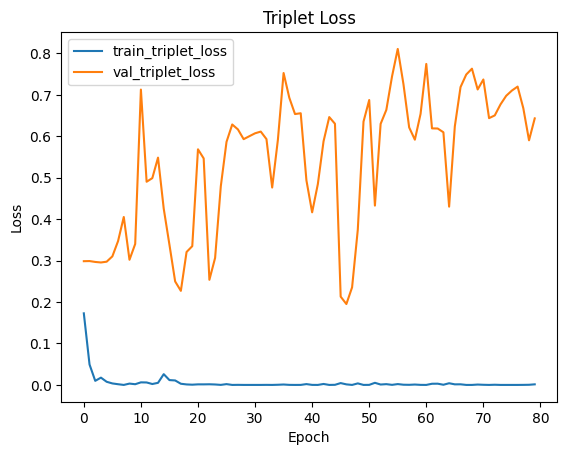

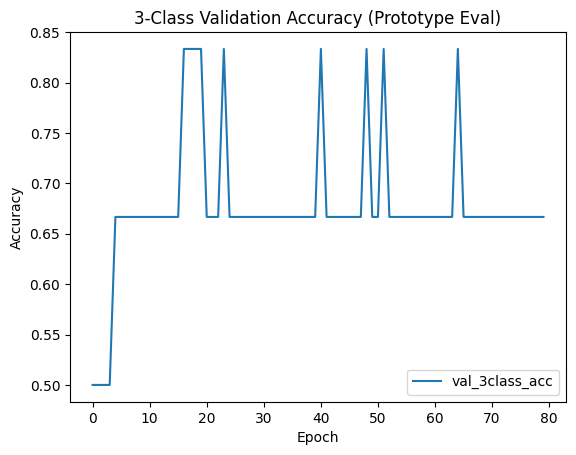

In [ ]:
plt.figure()
plt.plot(train_loss_hist, label="train_triplet_loss")
plt.plot(val_loss_hist, label="val_triplet_loss")
plt.title("Triplet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(val_acc_hist, label="val_3class_acc")
plt.title("3-Class Validation Accuracy (Prototype Eval)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/sea_turtle_models"
os.makedirs(SAVE_DIR, exist_ok=True)

ENCODER_PATH = os.path.join(SAVE_DIR, "triplet_conv4_encoder.keras")
encoder.save(ENCODER_PATH)
print("Saved:", ENCODER_PATH)


Saved: /content/drive/MyDrive/sea_turtle_models/triplet_conv4_encoder.keras
